In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.clean_data import basic_clean
from data.load_data import load_raw_data
from eda.summary import data_summary
from data.feature_engineering import prepare_model_data

In [2]:
df_raw = load_raw_data()
df = basic_clean(df_raw)

target = "annual_medical_cost"
log_target = "log1p_annual_medical_cost"

df = prepare_model_data(
    df,
    target_col=target,
    add_log=True,
    add_groups=True,
    add_tail_flags=False
)

print("Shape:", df.shape)
display(df.head())
display(data_summary(df))

Shape: (100000, 58)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,log1p_annual_medical_cost,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,2,0,1,0,0,8.844922,0,1,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,0,1,1,0,7.398548,0,2,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,2,1,0,1,0,8.944030,0,3,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,1,0,0,0,8.543108,0,1,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,1,0,1,0,7.439401,0,2,0


,dtype,missing_count,missing_pct,n_unique
alcohol_freq,str,30083,30.083,3
person_id,int64,0,0.000,100000
annual_medical_cost,float64,0,0.000,91299
log1p_annual_medical_cost,float64,0,0.000,91299
total_claims_paid,float64,0,0.000,56650
annual_premium,float64,0,0.000,55538
avg_claim_amount,float64,0,0.000,53071
monthly_premium,float64,0,0.000,12339
income,float64,0,0.000,2987
ldl,float64,0,0.000,1881


In [3]:
print(df.columns.tolist())

['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure', 'log1p_annual_medical_cost', 'hospitalizations_grouped', 'chronic_count_grouped', 'days_hospitalized_gro

In [4]:
print(df[target].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995]))
print("\nSkewness:", df[target].skew())
print("Kurtosis:", df[target].kurt())

mean_cost = df[target].mean()
median_cost = df[target].median()
p99_cost = df[target].quantile(0.99)

mean_log_cost = df[log_target].mean()
median_log_cost = df[log_target].median()

count    100000.000000
mean       3009.451907
std        3127.462822
min          55.550000
50%        2082.575000
75%        3707.957500
90%        6227.092000
95%        8570.350500
99%       15293.682200
99.5%     19212.947050
max       65724.900000
Name: annual_medical_cost, dtype: float64

Skewness: 4.030317894409436
Kurtosis: 32.559205950930746


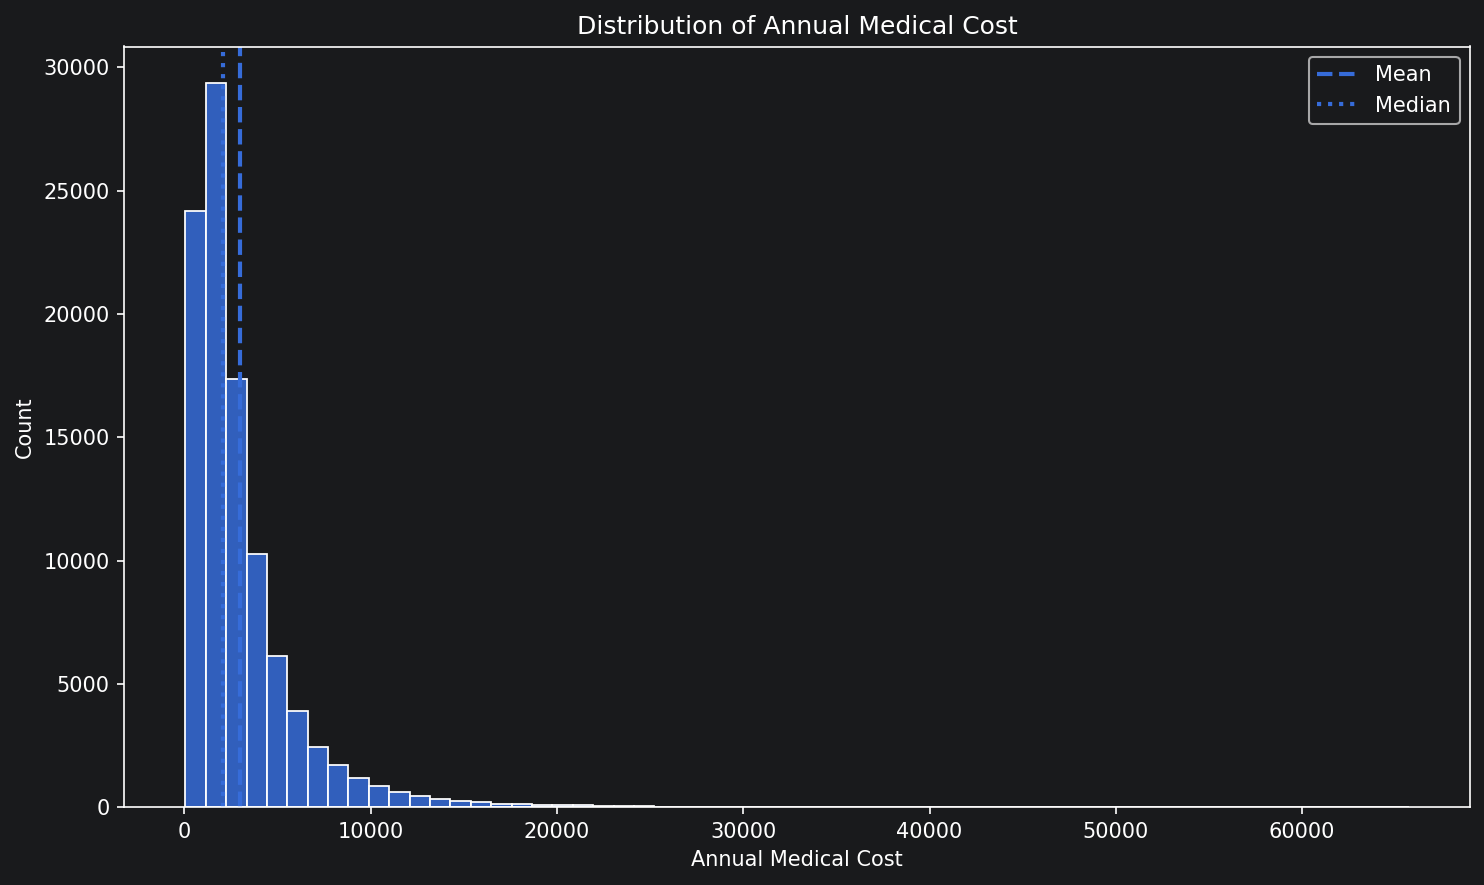

In [5]:
plt.figure(figsize=(10, 6), dpi=150)

sns.histplot(
    data=df,
    x=target,
    bins=60,
    alpha=0.85,
    edgecolor="white"
)

plt.axvline(
    mean_cost,
    linestyle="--",
    linewidth=2,
    label="Mean"
)

plt.axvline(
    median_cost,
    linestyle=":",
    linewidth=2,
    label="Median"
)

plt.title("Distribution of Annual Medical Cost")
plt.xlabel("Annual Medical Cost")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

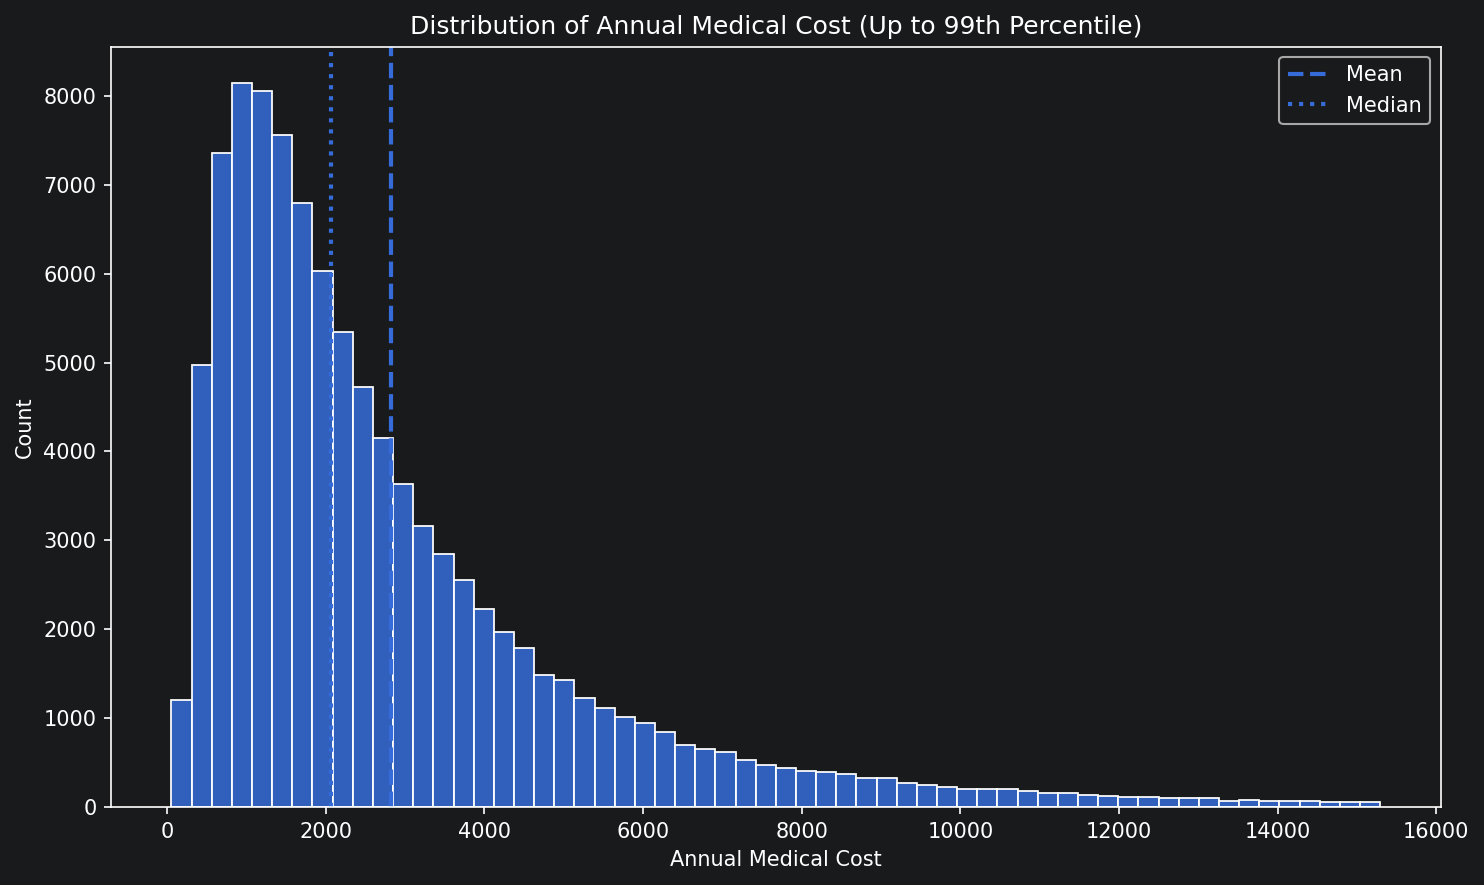

In [6]:
df_body = df[df[target] <= p99_cost]

plt.figure(figsize=(10, 6), dpi=150)

sns.histplot(
    data=df_body,
    x=target,
    bins=60,
    alpha=0.85,
    edgecolor="white"
)

plt.axvline(
    df_body[target].mean(),
    linestyle="--",
    linewidth=2,
    label="Mean"
)

plt.axvline(
    df_body[target].median(),
    linestyle=":",
    linewidth=2,
    label="Median"
)

plt.title("Distribution of Annual Medical Cost (Up to 99th Percentile)")
plt.xlabel("Annual Medical Cost")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

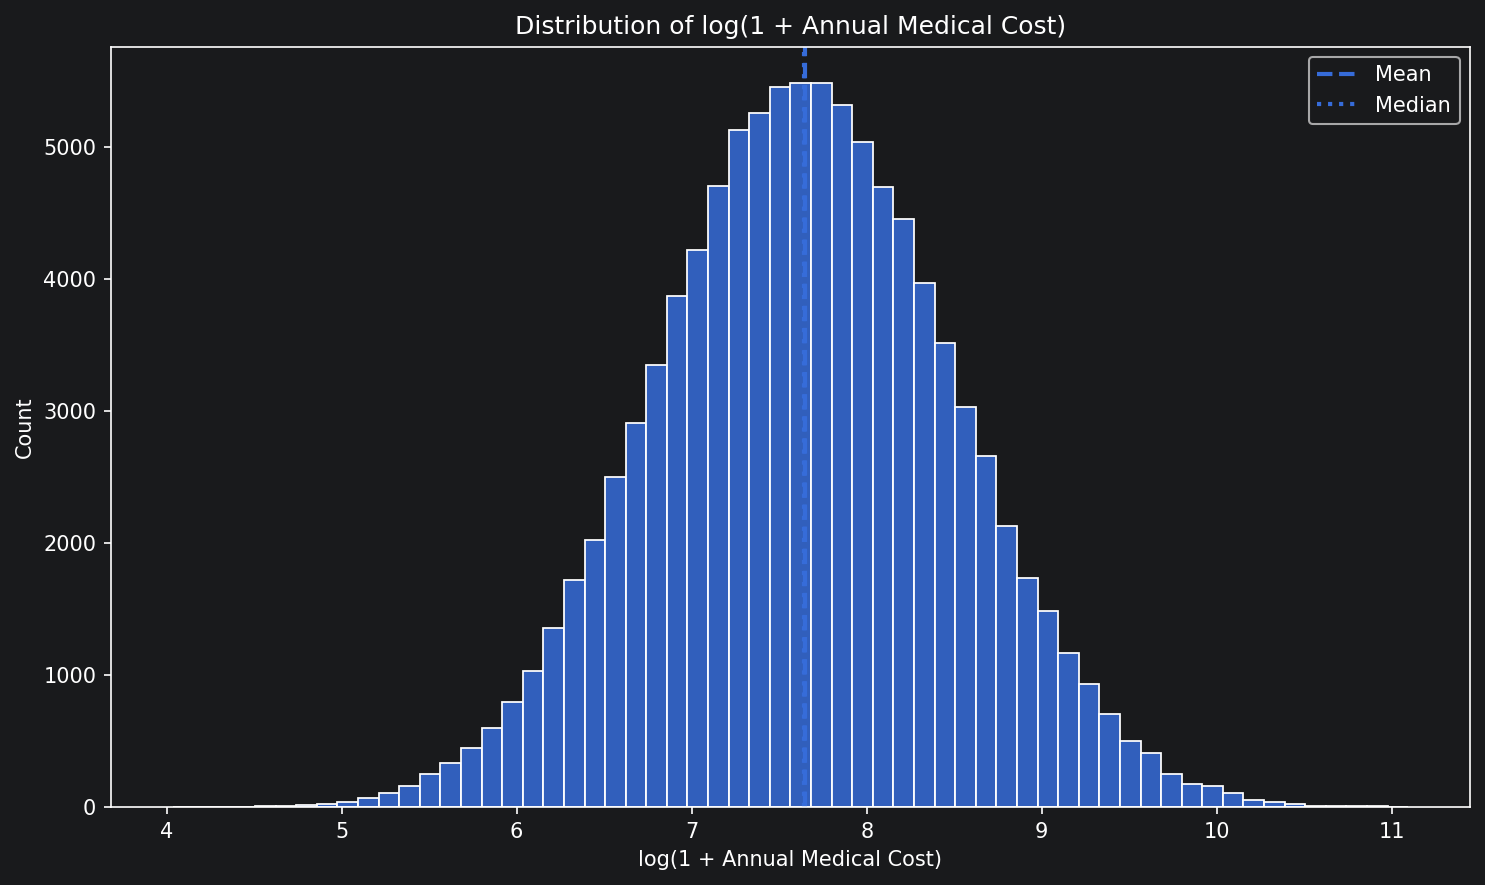

In [7]:
plt.figure(figsize=(10, 6), dpi=150)

sns.histplot(
    data=df,
    x=log_target,
    bins=60,
    alpha=0.85,
    edgecolor="white"
)

plt.axvline(
    mean_log_cost,
    linestyle="--",
    linewidth=2,
    label="Mean"
)

plt.axvline(
    median_log_cost,
    linestyle=":",
    linewidth=2,
    label="Median"
)

plt.title("Distribution of log(1 + Annual Medical Cost)")
plt.xlabel("log(1 + Annual Medical Cost)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

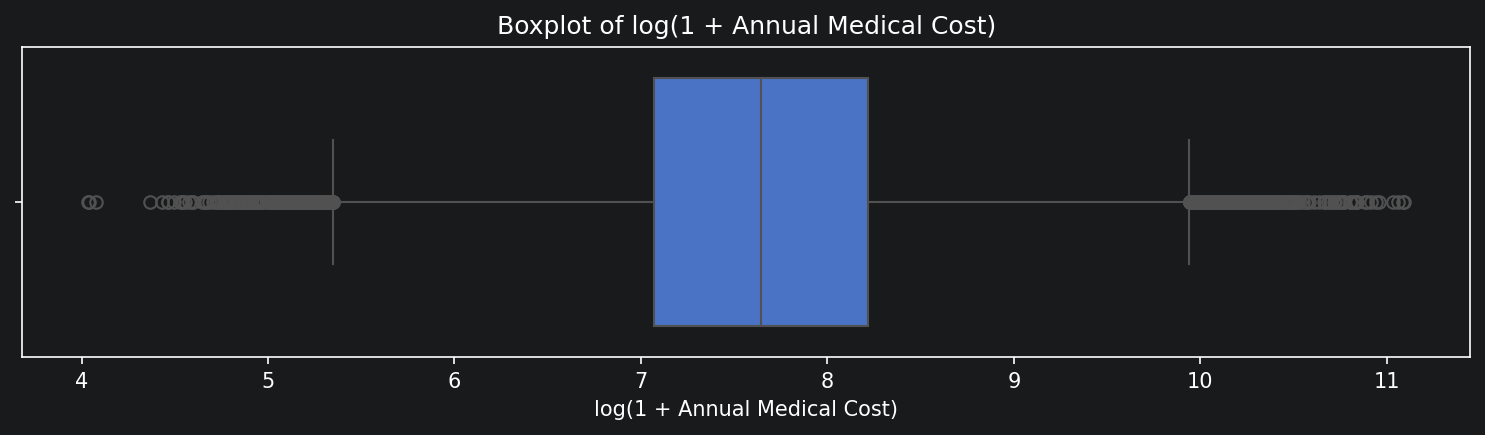

In [8]:
plt.figure(figsize=(10, 3), dpi=150)

sns.boxplot(
    data=df,
    x=log_target,
    showfliers=True
)

plt.title("Boxplot of log(1 + Annual Medical Cost)")
plt.xlabel("log(1 + Annual Medical Cost)")
plt.tight_layout()
plt.show()

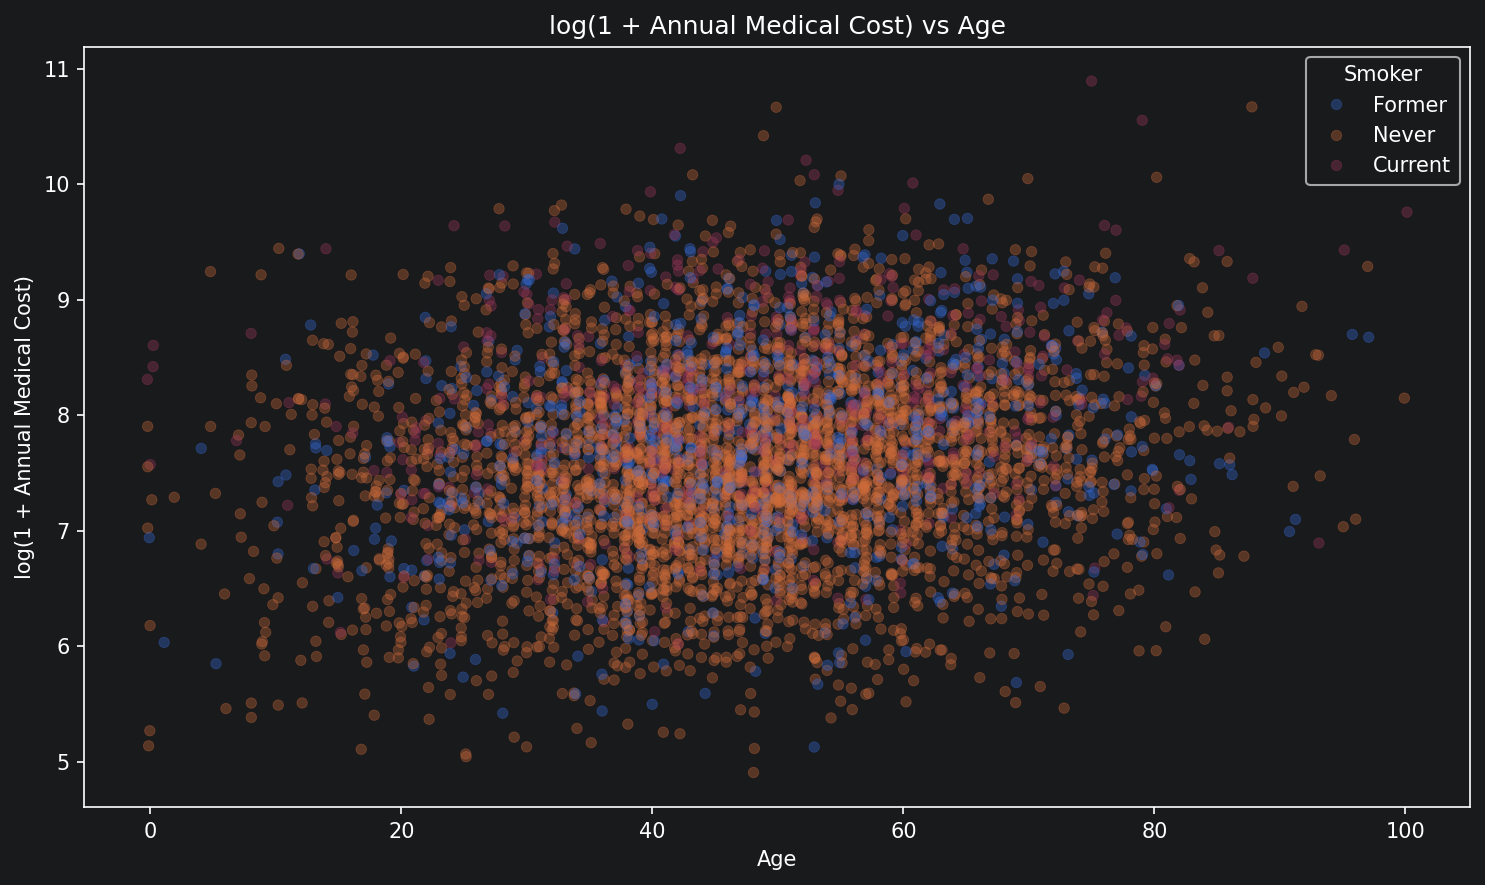

In [9]:
df_plot = df.sample(5000, random_state=42).copy()

rng = np.random.default_rng(42)
df_plot["age_jitter"] = df_plot["age"] + rng.uniform(
    -0.25,
    0.25,
    size=len(df_plot)
)

plt.figure(figsize=(10, 6), dpi=150)

sns.scatterplot(
    data=df_plot,
    x="age_jitter",
    y=log_target,
    hue="smoker",
    alpha=0.35,
    s=25,
    edgecolor=None
)

plt.title("log(1 + Annual Medical Cost) vs Age")
plt.xlabel("Age")
plt.ylabel("log(1 + Annual Medical Cost)")
plt.legend(title="Smoker")
plt.tight_layout()
plt.show()

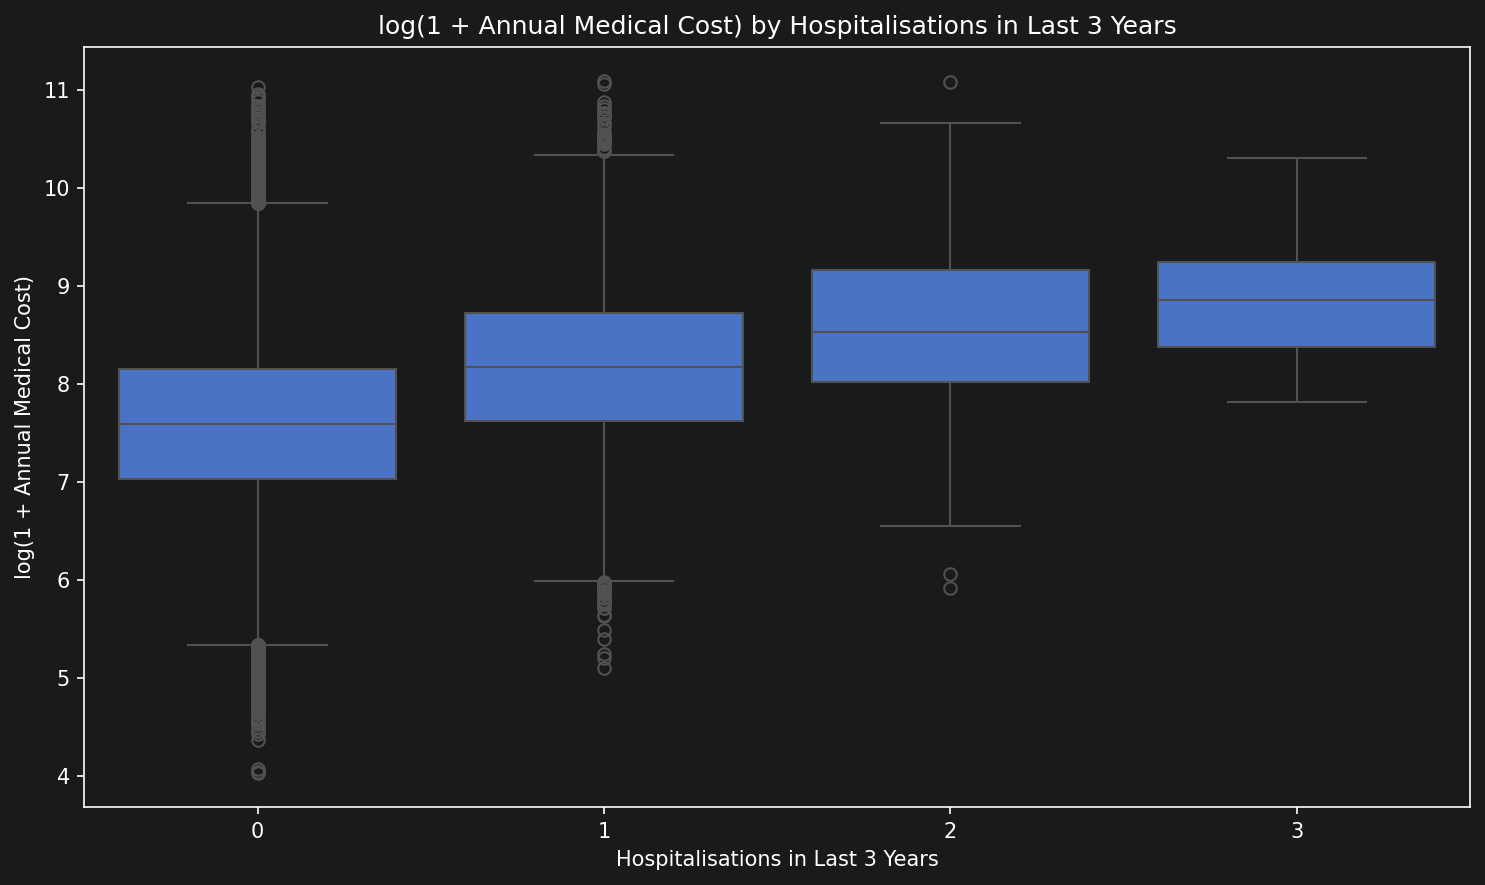

In [10]:
plt.figure(figsize=(10, 6), dpi=150)

sns.boxplot(
    data=df,
    x="hospitalizations_last_3yrs",
    y=log_target,
    showfliers=True
)

plt.title("log(1 + Annual Medical Cost) by Hospitalisations in Last 3 Years")
plt.xlabel("Hospitalisations in Last 3 Years")
plt.ylabel("log(1 + Annual Medical Cost)")
plt.tight_layout()
plt.show()

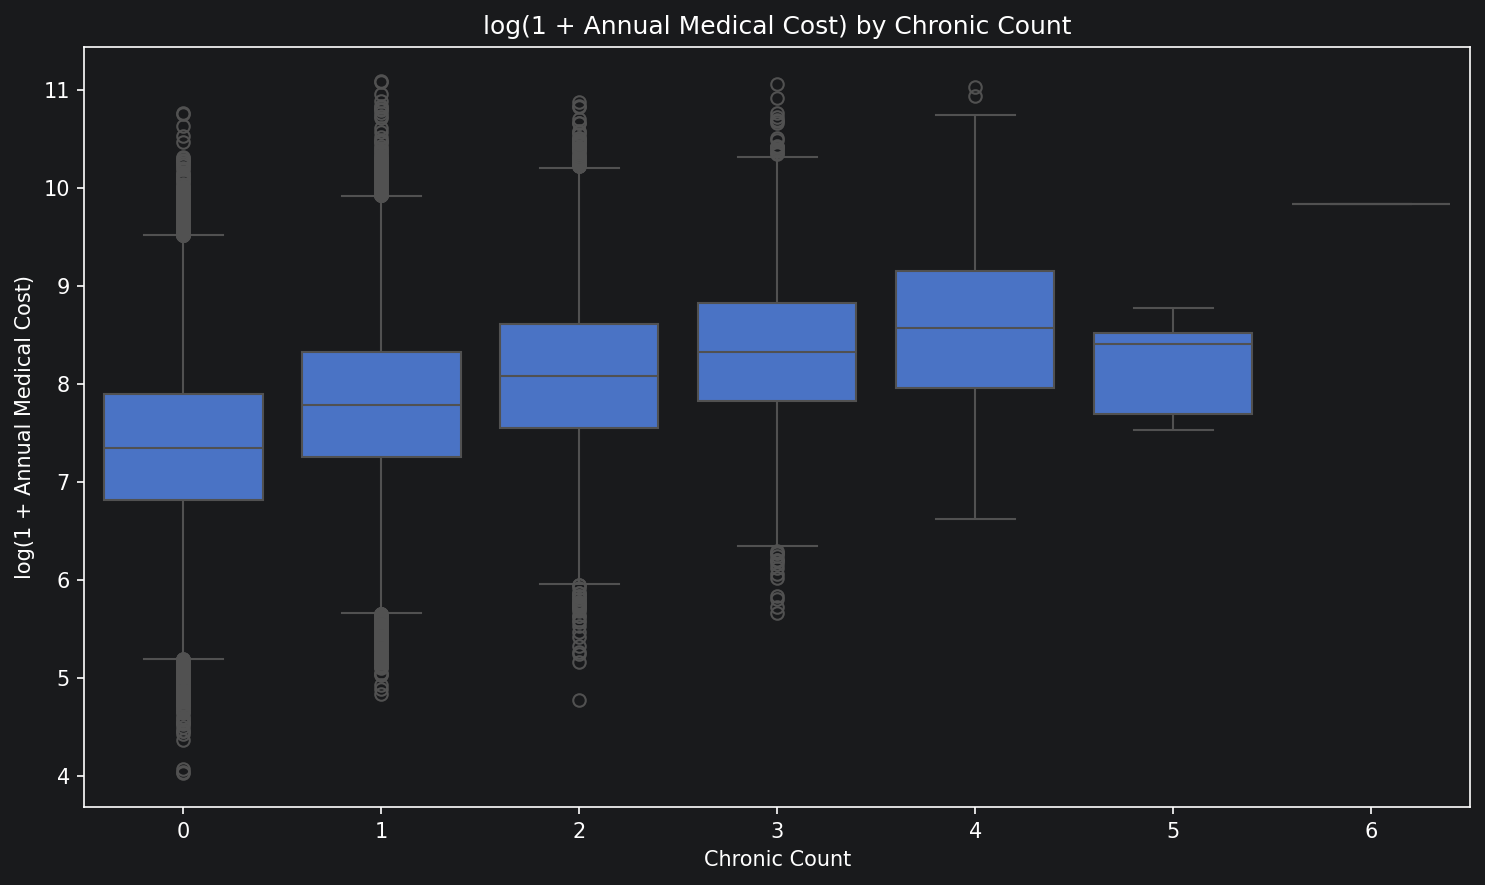

In [11]:
plt.figure(figsize=(10, 6), dpi=150)

sns.boxplot(
    data=df,
    x="chronic_count",
    y=log_target,
    showfliers=True
)

plt.title("log(1 + Annual Medical Cost) by Chronic Count")
plt.xlabel("Chronic Count")
plt.ylabel("log(1 + Annual Medical Cost)")
plt.tight_layout()
plt.show()

In [12]:
print(df["hospitalizations_last_3yrs"].value_counts().sort_index())
print()
print(df["chronic_count"].value_counts().sort_index())

hospitalizations_last_3yrs
0    91031
1     8582
2      379
3        8
Name: count, dtype: int64

chronic_count
0    46532
1    37579
2    13111
3     2452
4      316
5        9
6        1
Name: count, dtype: int64


In [13]:
print(df["hospitalizations_grouped"].value_counts().sort_index())
print()
print(df["chronic_count_grouped"].value_counts().sort_index())

hospitalizations_grouped
0     91031
1      8582
2+      387
Name: count, dtype: int64

chronic_count_grouped
0     46532
1     37579
2     13111
3      2452
4+      326
Name: count, dtype: int64


In [14]:
hospital_grouped_summary = (
    df.groupby("hospitalizations_grouped", observed=True)["annual_medical_cost"]
    .agg(
        n="size",
        mean="mean",
        median="median",
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .round(2)
)

hospital_grouped_summary

,n,mean,median,p90,p95,p99
hospitalizations_grouped,,,,,,
0,91031,2810.44,1977.55,5794.89,7889.32,13910.33
1,8582,4919.63,3539.12,9974.18,13216.47,23232.70
2+,387,7461.11,5108.38,16076.31,20864.75,30406.74


In [15]:
chronic_grouped_summary = (
    df.groupby("chronic_count_grouped", observed=True)["annual_medical_cost"]
    .agg(
        n="size",
        mean="mean",
        median="median",
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .round(2)
)

chronic_grouped_summary

,n,mean,median,p90,p95,p99
chronic_count_grouped,,,,,,
0,46532,2176.33,1558.97,4396.05,5949.58,10487.04
1,37579,3332.01,2415.40,6711.20,9023.71,15586.62
2,13111,4438.19,3249.83,8993.14,12001.39,20854.28
3,2452,5671.43,4137.85,11207.64,15269.95,26076.46
4+,326,7260.65,5260.05,15120.21,19244.68,30407.02


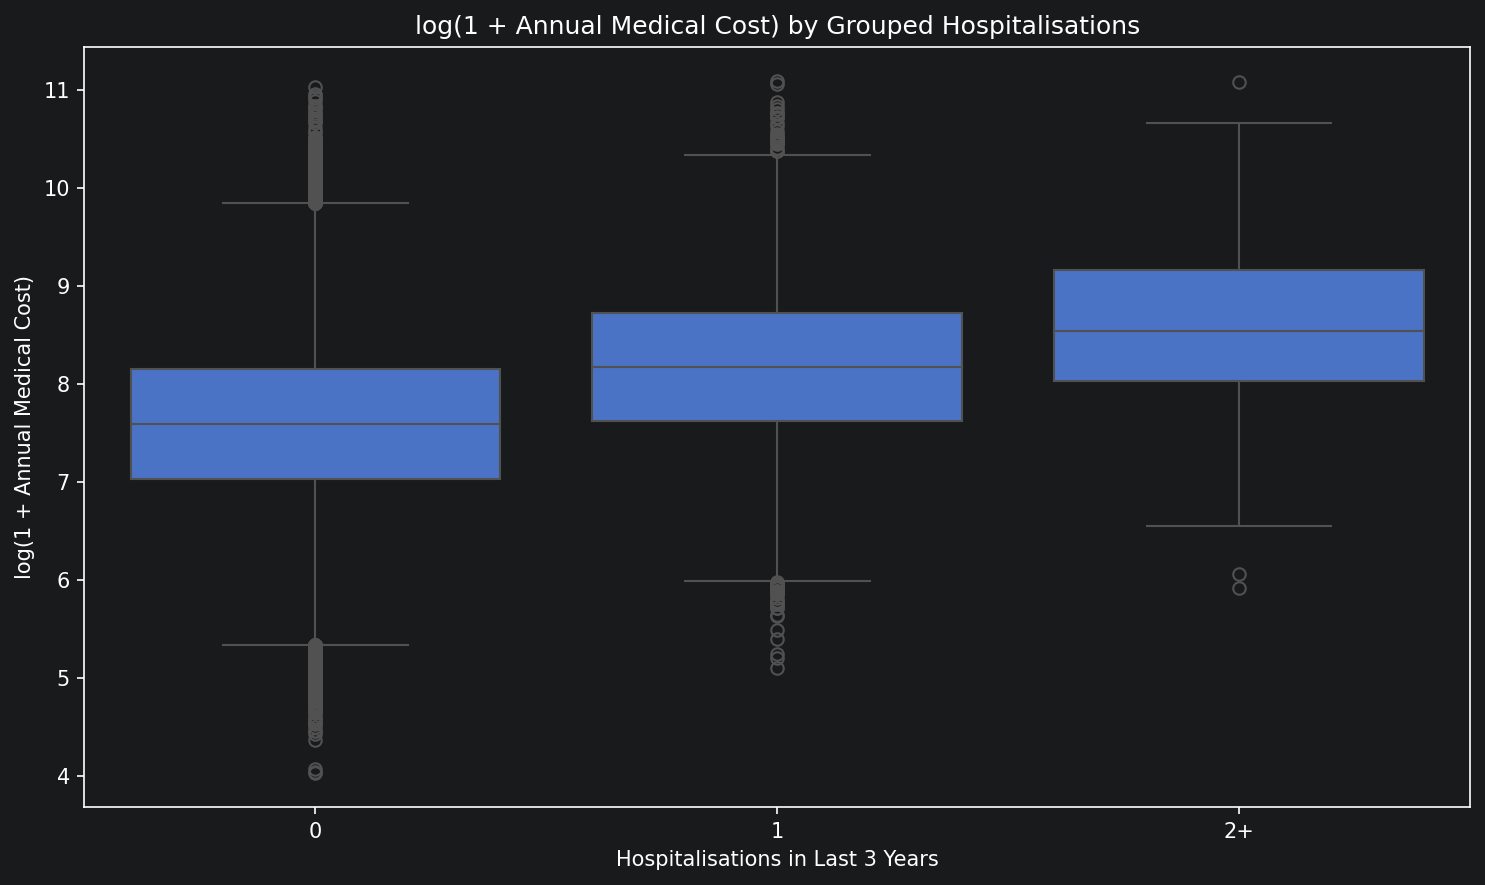

In [16]:
hospital_order = ["0", "1", "2+"]

plt.figure(figsize=(10, 6), dpi=150)

sns.boxplot(
    data=df,
    x="hospitalizations_grouped",
    y=log_target,
    order=hospital_order,
    showfliers=True
)

plt.title("log(1 + Annual Medical Cost) by Grouped Hospitalisations")
plt.xlabel("Hospitalisations in Last 3 Years")
plt.ylabel("log(1 + Annual Medical Cost)")
plt.tight_layout()
plt.show()

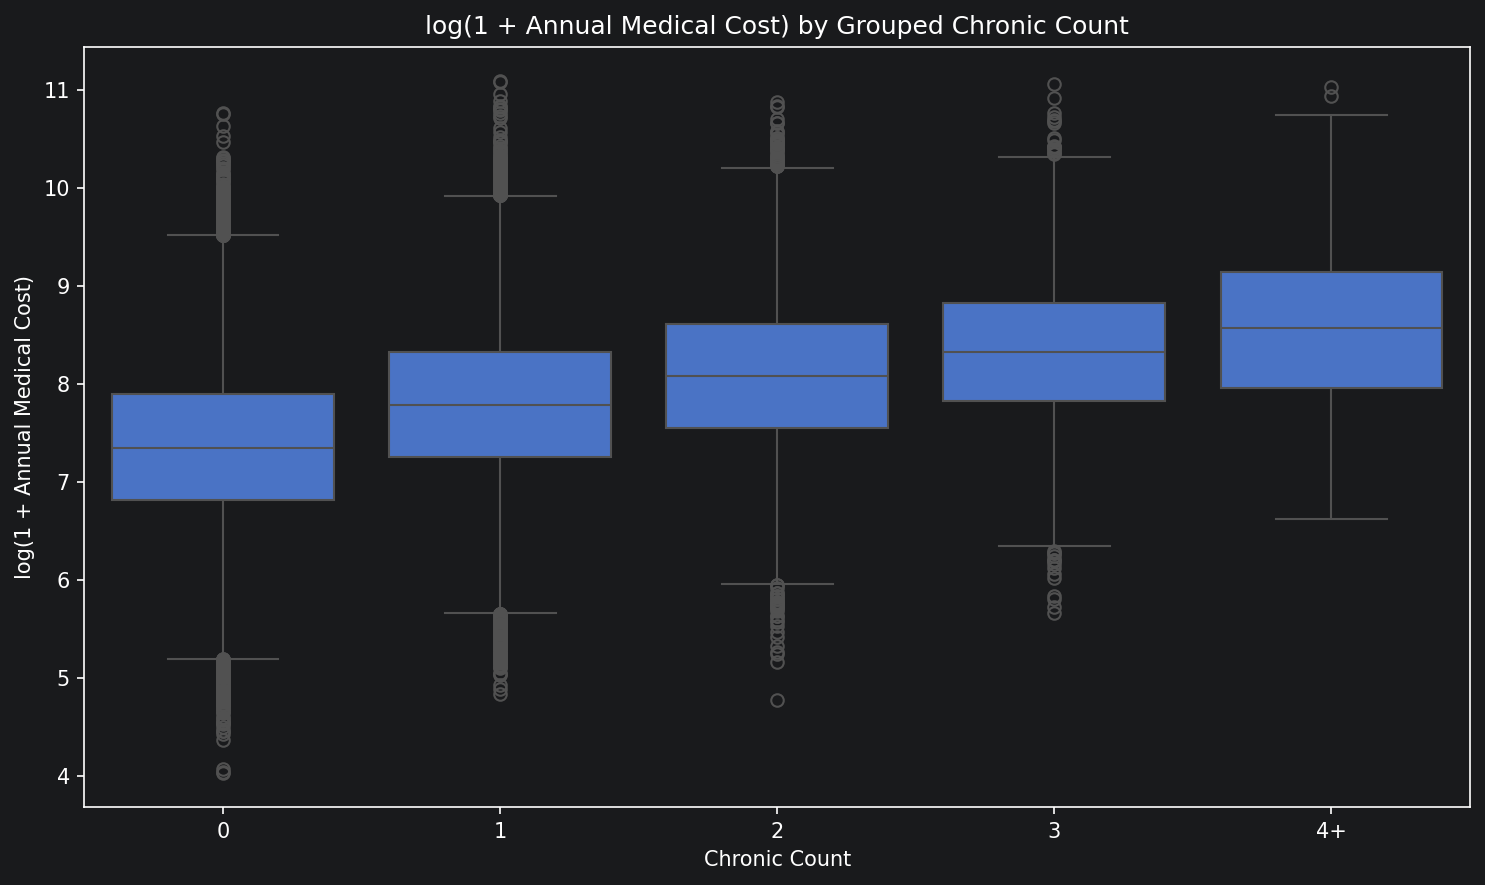

In [17]:
chronic_order = ["0", "1", "2", "3", "4+"]

plt.figure(figsize=(10, 6), dpi=150)

sns.boxplot(
    data=df,
    x="chronic_count_grouped",
    y=log_target,
    order=chronic_order,
    showfliers=True
)

plt.title("log(1 + Annual Medical Cost) by Grouped Chronic Count")
plt.xlabel("Chronic Count")
plt.ylabel("log(1 + Annual Medical Cost)")
plt.tight_layout()
plt.show()